# Experimental 4D-STEM Data Processing: Large FOV $\text{MoS}_2-\text{MoSe}_2$ Lateral Heterojunction Superlattice

In [1]:
# Import the python script containing the helper functions and classes
from fourdenoise import *
from kin_diff_sim import generate_library, get_tilts
plt.rcParams['font.family'] = 'Arial'

## 1. Data Loading and Preprocessing

### 1.1. Load and Visualize Raw 4D-STEM Data

Load your dataset using `HyperData(<<your_filepath_here>>)`

In [2]:
HyperData?

Init signature:
HyperData(
    data,
    real_units: str = None,
    real_conv_factor: float = None,
    reciprocal_units: str = None,
    reciprocal_conv_factor: float = None,
    polar_metadata: dict = None,
    center_beam_metadata: dict = None,
)
Docstring:      <no docstring>
File:           c:\users\haloe\documents\codewriting\4denoise_git\fourdenoise.py
Type:           type
Subclasses:     

In [3]:
filepath = "C:/Users/haloe/Documents/CodeWriting/pythonCodes/HanLab/Ripple/3d_Strain_mapping_paper_data/scan_x256_y256.raw"

mag = 75 # 75000X magnification
conversion_factor = 0.46*840/mag # nm/px
print(conversion_factor)

5.152


In [4]:
# Instantiate as a 4Denoise HyperData object
superlattice_data = HyperData(filepath, real_units='nm', real_conv_factor=conversion_factor)

We start by finding the electron dose over the dataset according to the acquired intensities on the diffraction patterns

In [16]:
# Conversion to electron-hit events per real-space scan position (pixel)
tot_sum = superlattice_data.array.sum(axis=(2,3))

In [17]:
mean_e_hits = np.mean(tot_sum)/151 # The '151' comes from the EMPAD detector,  a conversion factor into number of electrons

unit_conversion = 10 # Å/nm
# area_per_pixel = (conversion_factor*unit_conversion)**2 # Å^2
area_per_pixel = np.pi*(14.054)**2/4 # FWHM based on convergence angle
electron_dose = mean_e_hits/area_per_pixel # e/Å^2

print(rf"The electron dose for this dataset is approximately {electron_dose} e/Å^2")

The electron dose for this dataset is approximately 166.39718381078927 e/Å^2


Make a HAADF detector and see the resulting virtual image

In [5]:
superlattice_data.virtual_image?

Signature:
superlattice_data.virtual_image(
    annulus=None,
    *,
    radius=None,
    centers=None,
    mask=None,
    theta_range=None,
    detector_units='auto',
    axis_units='auto',
    vmin=None,
    vmax=None,
    grid=True,
    num_div=10,
    plot_mask=False,
    grid_color='black',
    axes=True,
    return_detector=False,
)
Docstring:
Form a real-space virtual image using a reciprocal-space detector.

The detector type is inferred from exactly one of these specifications:

- ``annulus=(inner_radius, outer_radius)`` for a centered annulus.
- ``radius`` and ``centers`` for one or more Cartesian disks.
- ``mask`` for an arbitrary Boolean or weighted detector.

Parameters
----------
annulus : array-like of two floats or None, optional
    Inner and outer detector radii. Interpreted according to
    ``detector_units``. For Cartesian data the annulus is centered at
    the diffraction origin. For polar data it selects a radial ``kr``
    interval.
radius : float or array-like 

<Figure size 1000x1000 with 0 Axes>

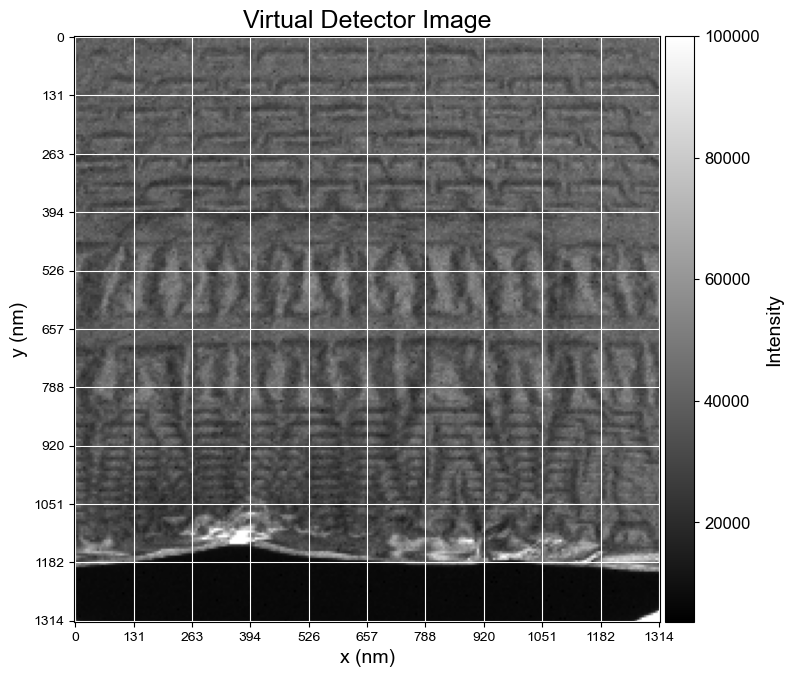

In [7]:
rmin = 37
rmax = 50

plt.figure(figsize=(10,10))
haadf = superlattice_data.virtual_image(annulus=(rmin, rmax), axes=True, grid_color='white', detector_units='pixels', vmax=1e5)

We crop the part of the dataset (in real-space) which displays vaccuum, remove region with artifacts, and visualize the result for better contrast

<Figure size 1000x1000 with 0 Axes>

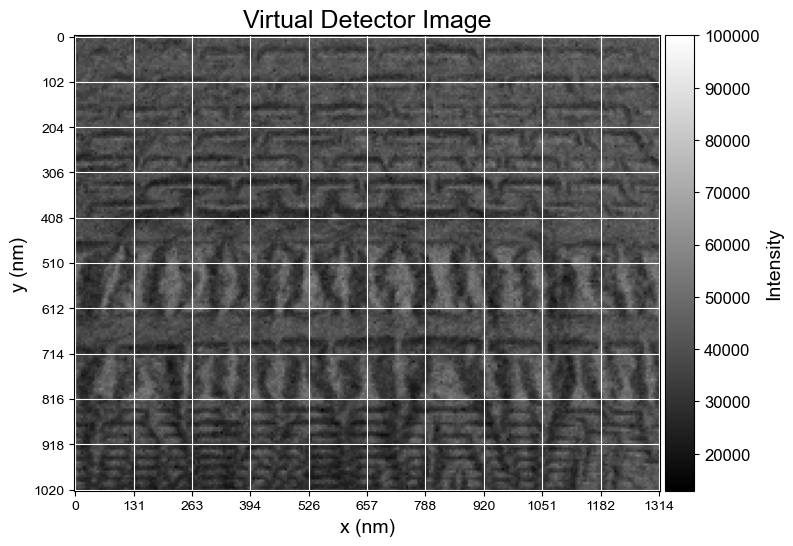

In [8]:
superlattice_data = superlattice_data.crop(ylim=(0,199), real_limit_units='pixels')

plt.figure(figsize=(10,10))
haadf = superlattice_data.virtual_image(annulus=(rmin, rmax), plot_mask=False, axes=True, grid_color='white', detector_units='pixels', vmax=1e5)

### 1.2. Align Diffraction Patterns in 4D-STEM Data

We employ the `alignment` method available through the `HyperData` object. Note the improvement in precision of the center beam locations and the minimization of the center-beam's variation in position.

In [21]:
superlattice_data.alignment?

Signature:
superlattice_data.alignment(
    r_center=5,
    iterations=1,
    center=None,
    method='com',
    search_radius=None,
    enforce_square=False,
    fit_radius=False,
    radius_range=None,
    radius_step=1,
    radius_operation='mean',
    radius_reference_dp=None,
    template='disk',
    trench_width=1.0,
    kernel_amp=1.0,
    trench_amp=-0.5,
    gaussian_sigma=None,
)
Docstring:
Align the diffraction patterns through the Center of mass of the center beam

Parameters
----------
r_center : float
    Radius of the central peak or disk in pixels.
iterations : int
    Number of iterations for the center-of-mass method. Ignored for
    the disk-template method.
center : tuple or None
    Approximate reference disk center ``(ky, kx)``. Defaults to the
    geometric k-space center ``((ky - 1)/2, (kx - 1)/2)``. When
    ``fit_radius=True`` or ``radius_range`` is provided, this center is
    refined on the representative diffraction pattern before aligning
    individual di

In [9]:
superlattice_data = superlattice_data.alignment(method='disk',
                                                fit_radius=True, 
                                                radius_range=[0.1,3], 
                                                radius_step=0.01, 
                                                iterations=2,
                                                search_radius=2.5,
                                                enforce_square=False)

Selected disk template reference from operation='mean': radius=2.2400, center=(64.0000, 64.0000) (score=0.8786).


Template-matching disk centers: 100%|████████████████████████████████████████████████| 199/199 [05:44<00:00,  1.73s/it]


Initial disk-center standard deviation (ky, kx): (0.5475, 0.3150)
Initial disk center (ky, kx): (64.1611, 63.7589)
Cropping diffraction patterns to common k-space shape (125, 127).


Template-matching disk centers: 100%|████████████████████████████████████████████████| 199/199 [04:12<00:00,  1.27s/it]


Disk-center residual before iteration (2/2) standard deviation (ky, kx): (0.1699, 0.0912)
Disk center before iteration (2/2) (ky, kx): (62.0634, 62.9419)


Template-matching disk centers: 100%|████████████████████████████████████████████████| 199/199 [01:22<00:00,  2.41it/s]

Final disk-center standard deviation (ky, kx): (0.0215, 0.0153)
Final disk center (ky, kx): (62.0069, 62.9999)


### 1.3. Fix Global Elliptical Distortions

We employ the `fix_elliptical_distortions` method available through the `HyperData` object. This method fits and ellipse over an annular region and determines the necessary transformations that have to be made to the diffraction patterns to result in a more circular diffraction. Note how the ellipses' axis measurements 'a' and 'b' become more similar, hence less visible/quantifiable ellipticity.

In [ ]:
# Whe choose the inner and outer rings so that they encompass the second-order peaks, as they are of great brightness
# TIP: Use `superlattice_data.virtual_image(annulus=(r, R), plot_mask=True)` to see the annular mask drawn overlapped over mean diffraction pattern

r = 43.5
R= 51.5

superlattice_data = superlattice_data.fix_elliptical_distortions(r=43.5, R=51.5, return_fix=True)

In [472]:
np.save('./superlattice_data_processed.npy', superlattice_data.array)

## 2. Data Processing: Peak-finding and Intensity Integration

### 2.1. Find Bragg peaks for a reference diffraction pattern (from a flat region)

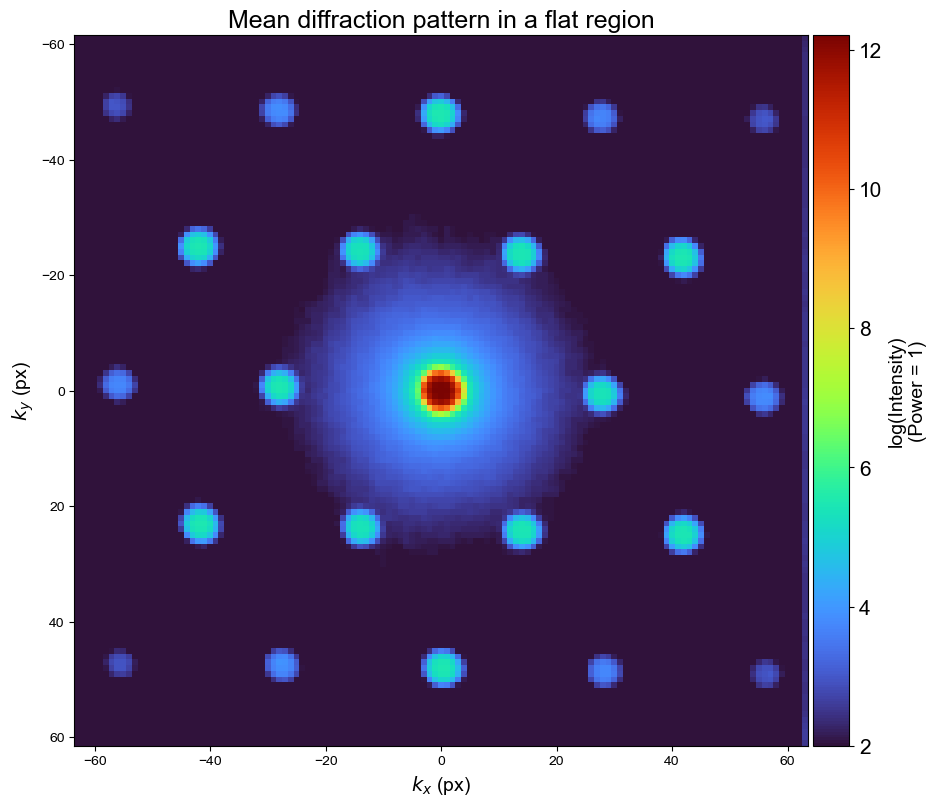

In [27]:
# Note that (125, 133) are the pixel coordinates of a flat region based on the HAADF images acquired above
flat_dp = superlattice_data.get_dp(y=(125,133)) 
flat_dp.show(vmin=2, title="Mean diffraction pattern in a flat region")

We find the reference Bragg peak positions using one of two options (more methods available in **4Denoise** but not implemented in this notebook)

#### Option 1: Using `find_peaks' (parameter tuning required)

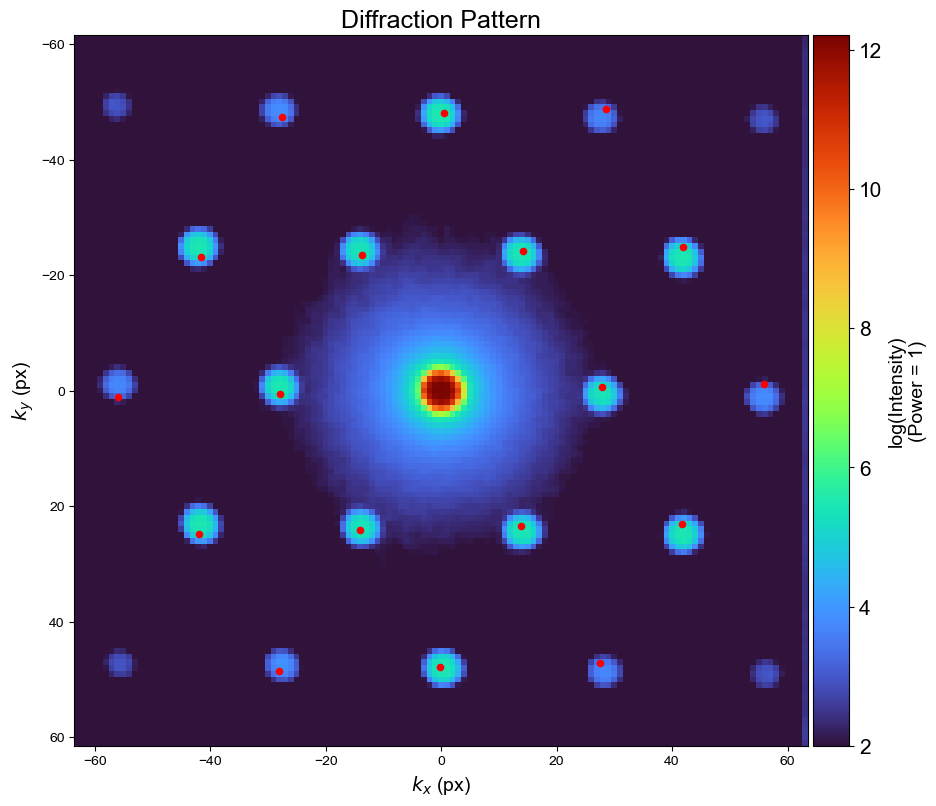

In [36]:
ref_coords = flat_dp.get_peaks(
                               radius=0.01,
                               trench_width=0.1,
                               kernel_amp=10,
                               trench_amp=0.1,
                               threshold_rel=0.01,
                               r_range=(10, 60),
                               n_fold=6,
                               sym_mode='both',
                               min_distance=10,
                               sym_tolerance_px=6,
                              )
len(ref_coords)

ref_coords = flat_dp.get_centers(r=5, ref_coords=ref_coords, method='CoM')
radii = np.full(ref_coords.shape[0], peak_radius)

flat_dp.show(vmin=2, axes=True, coords=ref_coords, c='red', s=20)

In [37]:
ref_coords

array([[ 12.39355444,  34.90742465],
       [ 13.21800479,  62.8475336 ],
       [ 13.84154464,  90.55849991],
       [ 36.17732061,  21.05191184],
       [ 36.88014995,  48.99178233],
       [ 37.53396783,  76.86668812],
       [ 37.98253406, 104.75868218],
       [ 59.97820978,   7.09704191],
       [ 60.49408306,  35.10915222],
       [ 61.66810586,  90.84110315],
       [ 62.09846836, 118.91681132],
       [ 84.14597836,  21.3690408 ],
       [ 84.51785529,  49.22235904],
       [ 85.1985119 ,  77.18332872],
       [ 85.85018919, 104.89533029],
       [108.36653121,  35.3687633 ],
       [109.00146756,  63.42542495],
       [109.70056835,  91.54376416]])

#### Option 2: Using `select_peaks' (manual option)

**Note:** This method might fail to load. This will be fixed in a latter version of 4Denoise. 

The image below shows an example of the pop-up interactive figure

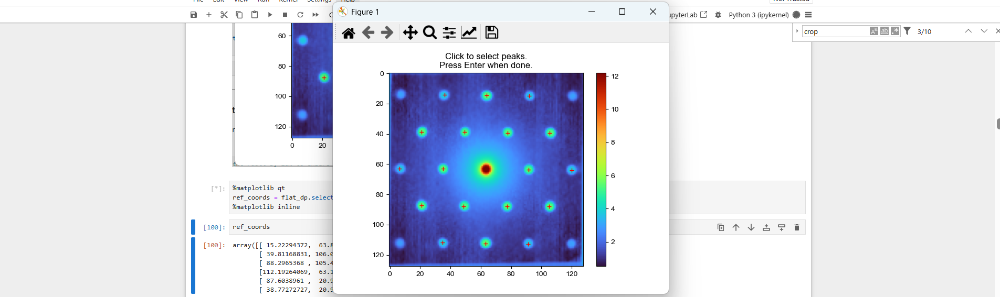

In [117]:
%matplotlib qt
ref_coords = flat_dp.select_peaks(cmap='turbo',)
%matplotlib inline

In [118]:
ref_coords

array([[ 39.46536797,  77.6991342 ],
       [ 63.70779221,  91.55194805],
       [ 87.95021645,  77.35281385],
       [ 87.95021645,  48.60822511],
       [ 63.01515152,  35.1017316 ],
       [ 38.77272727,  49.3008658 ],
       [ 39.46536797, 105.4047619 ],
       [ 87.95021645, 105.05844156],
       [112.53896104,  63.15367965],
       [ 87.25757576,  20.9025974 ],
       [ 38.77272727,  20.9025974 ],
       [ 14.53030303,  63.84632035],
       [ 14.87662338,  91.8982684 ],
       [ 64.05411255, 119.95021645],
       [112.88528139,  91.20562771],
       [111.84632035,  34.75541126],
       [ 63.01515152,   6.35714286],
       [ 14.18398268,  36.14069264]])

### 2.2. Find the center-of-mass for all Bragg peaks for all diffraction patterns

Here, we use the array **ref_coords** as the reference (starting point "guess") for the location of the peaks' center-of-mass.

In [38]:
all_centers = superlattice_data.get_centers(r=5, ref_coords=ref_coords, method='CoM')

Computing centers (4D): 100%|████████████████████████████████████████████████████████| 199/199 [10:24<00:00,  3.14s/it]


In [397]:
np.save('all_centers.npy', all_centers)

### 2.3. Compute Intensities 

We compute the intensity for the first 6 peaks of interest.

In [43]:
all_intensities = superlattice_data.get_intensities(r=5.25, 
                                                    centers=all_centers, 
                                                    method='CoM')

print(f"A total of {all_intensities.shape[2]} intensities were calculated for each diffraction pattern.")

Calculating intensities: 100%|███████████████████████████████████████████████████████| 199/199 [07:54<00:00,  2.39s/it]

A total of 18 intensities were calculated for each diffraction pattern.


We normalize based on flat region intensities.

In [44]:
flat_intensities = flat_dp.get_intensities(r=5.25, 
                                           ref_coords=ref_coords, 
                                           method='CoM')

all_intensities /= flat_intensities

In [396]:
np.save('all_intensities.npy', all_intensities)

From the 18 Bragg peaks, the first 6 correspond to first order, the next 6 to second order, and the last 6 to 3rd order.
We display a dark-field virtual image for each of the peaks, order left to right top to bottom

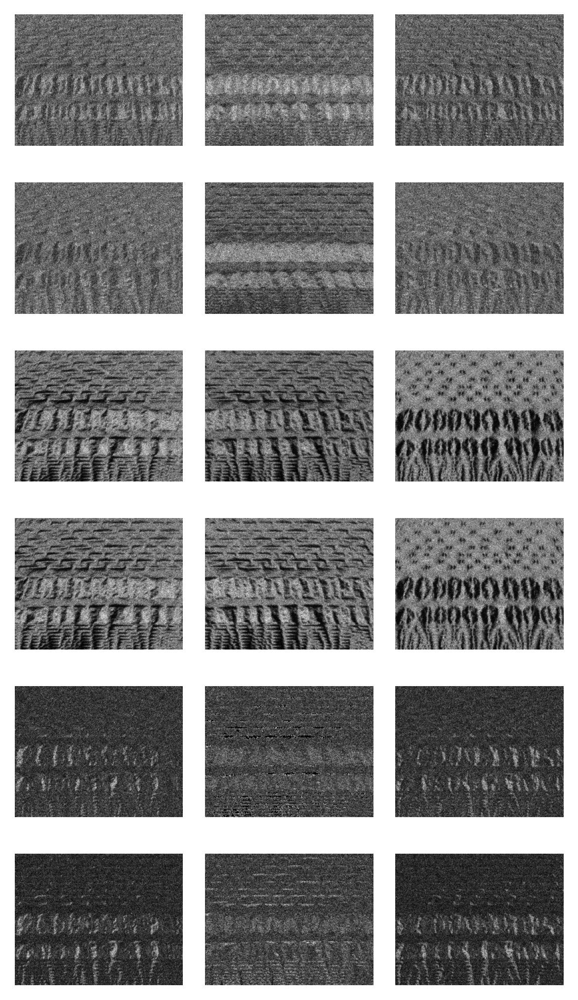

In [18]:
# We will now plot a virtual image for each of the peaks
fig, axes = plt.subplots(6, 3, figsize=(4, 7), dpi=300)

for i in range(18):
    ax = axes[i//3, i % 3]  # Determine position in 6x3 grid
    ax.imshow(all_intensities[:, :, i], cmap='gray')  # Adjust slicing as necessary
    ax.axis('off')
    # ax.set_title(f'Peak {i + 1}')  # Title for each plot

plt.tight_layout()
plt.show()

## 3. Three-dimensional Reconstruction

In order to map the **out-of-plane topology** of the material in question, we define two "tilt descriptors" $(\phi, \theta)$, where the angle $\phi$ is the azimuthal angle and $\theta$ the elevation angle. Each diffraction pattern in the four-dimensional dataset has a unique pair of tilt descriptors which describes its orientation.

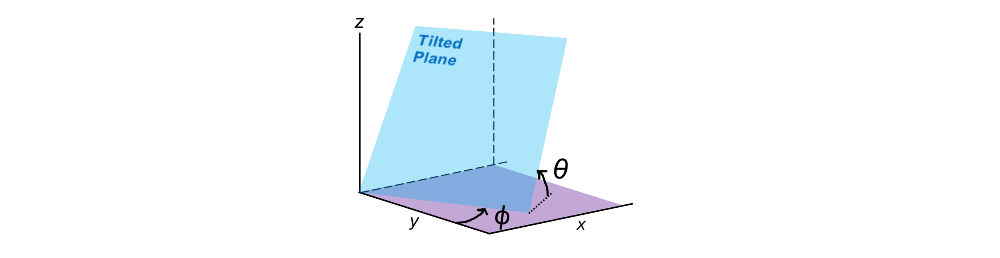

### 3.1. Generate a Library of Simulation Data

We first generate a library of simulations based on a **kinematic diffraction model**. This model is based on that in  [S. H. Sung, et al (2019)](https://doi.org/10.1103/PhysRevMaterials.3.064003) and allows for a forward mapping $f(\phi, \theta) = [I_1 ... I_6]$ correpsonding to the intensities of six Bragg peaks at a user-defined "diffraction order" (the higher the order, the further the peaks from the central electron beam). 

In the following step, we input a range of combinations of $(\phi, \theta)$, where the range of $\phi$ is defined by the parameter `phi_range` and, that of $\theta$, by `theta_range`. We specify the number of values tested using `num_phis` and `num_thetas`. 

In [35]:
sim_ints_array = generate_library(phi_range=(0,360), num_phis=181,       # Specify range and number of values simulated    
                                  theta_range=(0,30), num_thetas=151,     # Specify range and number of values simulated        
                                  save=True, fname='sim_ints_MoSe2.npy', # Optionaly, save the generated library
                                  material='MoSe2', a=3.32, order=2,     # Kinematic diffraction simulation arguments
                                  normalization='flat_max', keV=80,      # Kinematic diffraction simulation arguments
                                 )

print(r"([Number (" + "\N{greek small letter phi}," + \
       " \N{greek small letter theta}" + ") Pairs], [\N{greek small letter phi}," + \
       " \N{greek small letter theta}, I₁, I₂, I₃, I₄, I₅, I₆]) =", sim_ints_array.shape)

Generating library of (phi, theta, intensities): 100%|██████████████████████████| 27331/27331 [02:13<00:00, 204.95it/s]

Saved all data as: sim_ints_MoSe2.npy
([Number (φ, θ) Pairs], [φ, θ, I₁, I₂, I₃, I₄, I₅, I₆]) = (27331, 8)


In [19]:
# Alternatively, directly load a previously generated library of kinematic diffraction simulations
sim_ints_array = np.load('sim_ints_MoSe2.npy')

In [20]:
sim_ints_array.shape

(27331, 8)

### 3.2. Compute Tilt Maps and Surface Gradients

We now find the optimal combinations of $(\phi, \theta)$ for each set of **second order intensities** $[I_1 ... I_6]$ extracted from each real-space position using the `get_tilts` function. The output `tilts` will be of shape (Real$_\text{Y}$, Real$_\text{X}$, 2), where the last index corresponds to the two values $\phi$ and $\theta$.

Finding optimal (phi, theta): 100%|██████████████████████████████████████████████████| 200/200 [05:09<00:00,  1.55s/it]


<Figure size 1000x1000 with 0 Axes>

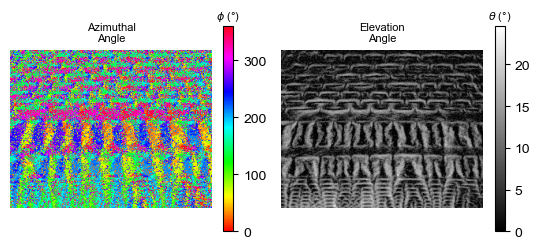

In [50]:
# Compute tilts
plt.figure(figsize=(10,10))
tilts = get_tilts(intensity_array=all_intensities[:,:,6:12],
                  show_result=True, figsize=(5.5, 5),
                  method='grid_search', 
                  loss='euclidean_distance', 
                  simDataArray=sim_ints_array)

In [395]:
np.save('./tilts.npy', tilts)

### 3.3 Reconstruct Surface

We convert the tilt maps into perpendicular surface gradients using the `get_gradients` function.

In [409]:
get_gradients?

Signature:
get_gradients(
    sol_array,
    rot_angle=0,
    show_result=False,
    invertY=False,
    invertX=False,
    cbar_fraction=0.04,
)
Docstring:
Calculate directional gradients from a solution array of (phi, theta) values.

This function computes the directional gradients (dz/dx and dz/dy) from a solution array that 
contains azimuthal (phi) and elevation (theta) angles. The gradients are computed considering 
a specified rotation angle. Optionally, the gradients can be visualized as 2D images.

Parameters
----------
sol_array : ndarray
    A 3D numpy array of shape (rows, cols, 2) where the last dimension represents the angles 
    (phi, theta) in radians.
rot_angle : float, optional
    The rotation angle in degrees to adjust the azimuthal angle (phi). Default is 0.
show_result : bool, optional
    If True, displays the gradients as images with colorbars. Default is False.
invertY : bool, optional
    If True, inverts the y-axis gradient. Default is False.
invertX : bool, 

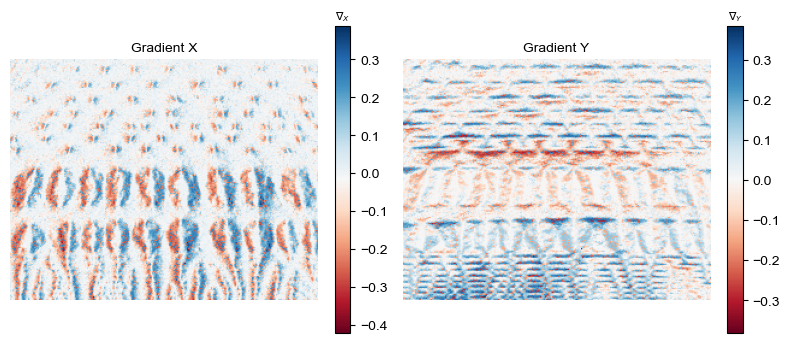

In [32]:
grads = get_gradients(tilts, 
                      rot_angle=150, # 'rot_angle' is for use to specify the positive/negative X and Y directions 
                      show_result=True, invertY=False, invertX=True,
                      cbar_fraction=0.0451)  # 'rot_angle' is for use to specify the positive/negatice X and Y directions

The gradients can then be directly inputted into `reconstruct_height` to obtain a height map.

In [34]:
hmap = reconstruct_height(xGrad=grads[:,:,0], 
                          yGrad=grads[:,:,1], 
                          y_bds_flat=(0,80), 
                          x_bds_flat=(0,255), 
                          iterations=10, 
                          threshold_percent=3, 
                          returnGradients=False,
                          max_window_size=3)

Reconstructing height: 100%|███████████████████████████████████████████████████████████| 10/10 [04:39<00:00, 27.93s/it]


(-0.5, 255.5, 199.5, -0.5)

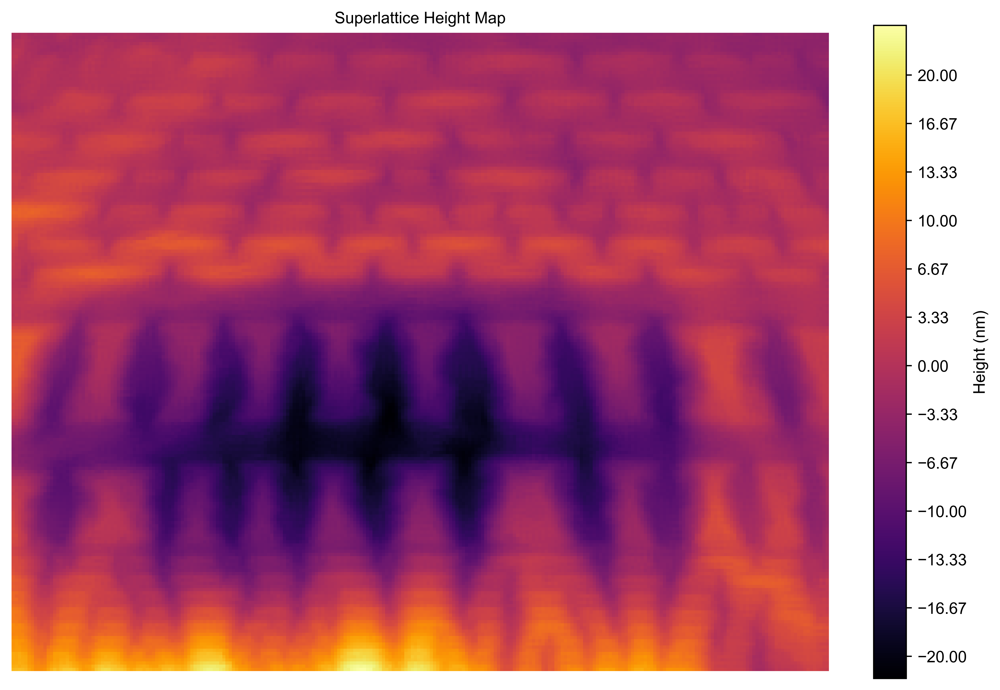

In [474]:
mag = 75 # 75000X magnification
conversion_factor = 0.46*840/mag #nm/px

plt.figure(figsize=(10,10), dpi=500)
plt.imshow(hmap*conversion_factor, cmap='inferno')
cbar = plt.colorbar(label='Height (nm)', ticks=np.linspace(-20, 20, 13),fraction=0.0365,)
plt.title('Superlattice Height Map', fontsize=10)
plt.axis('off')

In [394]:
np.save('./height_map.npy', hmap)

Save the data as `.mat` files for the interactive GUI in MATLAB.

In [1847]:
save_mat_data(hmap, 
              save_dir + '/height_map.mat', 
              'height_map')

save_mat_data(haadf, 
              save_dir + '/haadf.mat', 
              'haadf')

save_mat_data(tilts, 
              save_dir + '/tilts.mat', 
              'tilts')

For verification purposes, we now visualize the tilt maps and the gradient maps of the reconstructed height map.

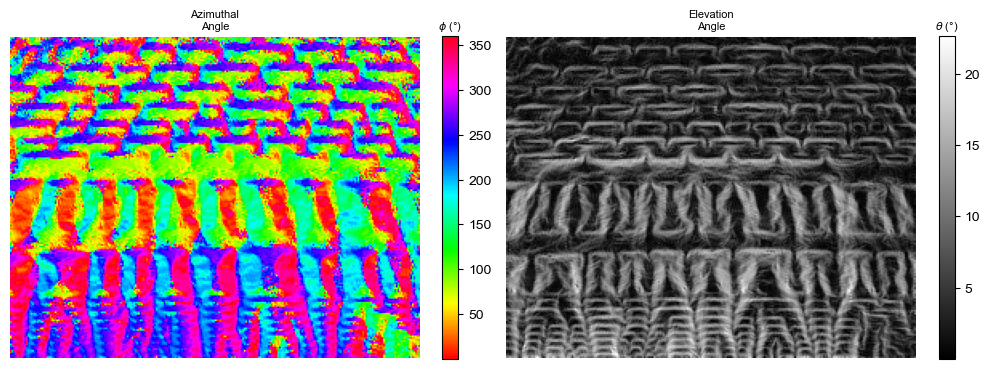

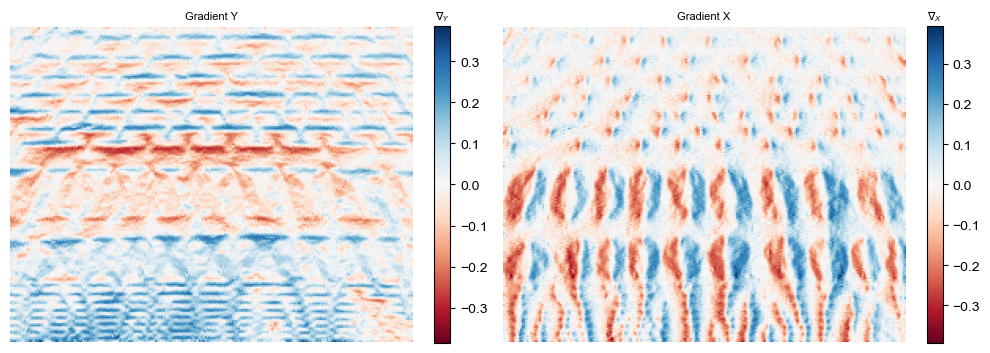

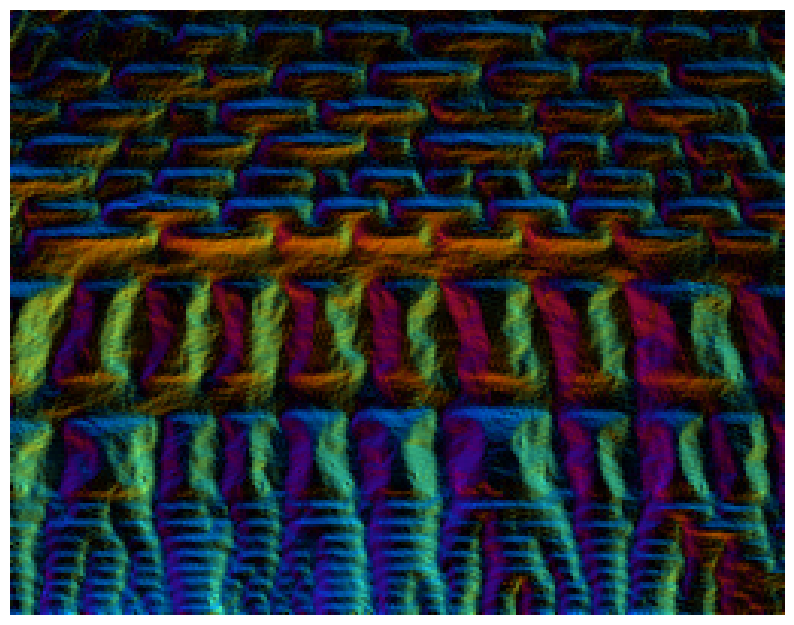

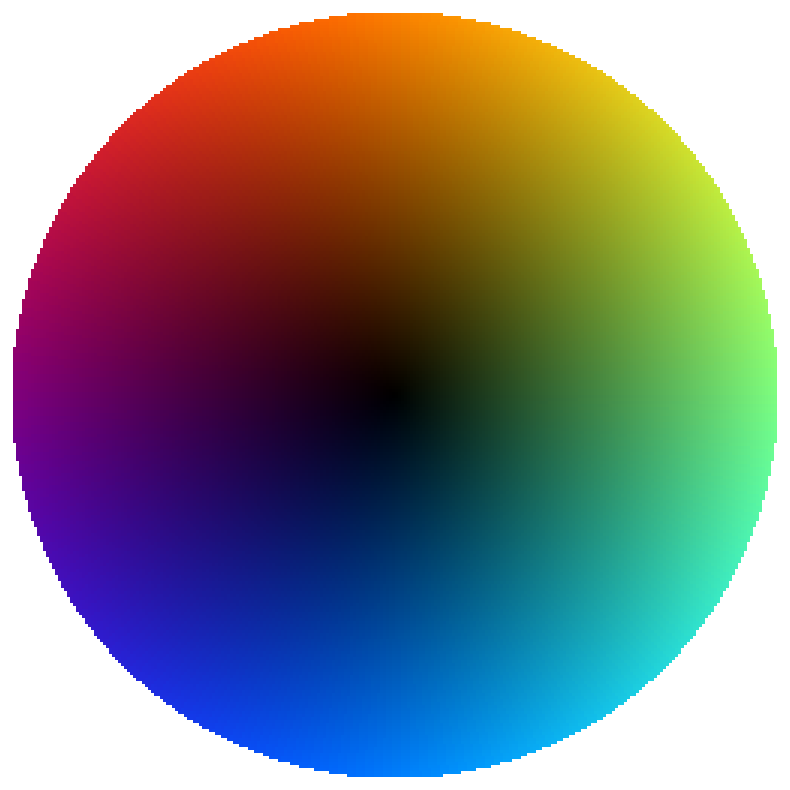

In [49]:
ripple_tilt_axis, ripple_tilt = get_surface_tilt_and_direction(hmap, units='rad', show_results=False)

tilts2 = np.stack((ripple_tilt_axis, 
                   ripple_tilt), axis=2)

fig, axs = plt.subplots(1, 2, figsize=(10, 6.25))

# Tilt axis (azimuth)
im1 = axs[0].imshow(np.degrees(tilts2[:, :, 0]), cmap='hsv')
axs[0].axis('off')
axs[0].set_title('Azimuthal\nAngle', fontsize=8)
cbar1 = fig.colorbar(im1, ax=axs[0], fraction=0.036)
cbar1.ax.set_title(r'$\phi$ (°)', fontsize=8, pad=5)

# Tilt magnitude (elevation)
im2 = axs[1].imshow(np.degrees(tilts2[:, :, 1]), cmap='gray')
axs[1].axis('off')
axs[1].set_title('Elevation\nAngle', fontsize=8)
cbar2 = fig.colorbar(im2, ax=axs[1], fraction=0.036)
cbar2.ax.set_title(r'$\theta$ (°)', fontsize=8, pad=5)

plt.tight_layout()
plt.show()

grads2 = get_gradients(tilts2, rot_angle=180)
fig, axs = plt.subplots(1, 2, figsize=(10, 6.25))

# Y-gradient 
lim_val = np.max(np.abs(grads2[:,:,0]))
im1 = axs[0].imshow(grads2[:,:,0], cmap='RdBu', vmin=-lim_val, vmax=lim_val)
axs[0].axis('off')
axs[0].set_title('Gradient Y', fontsize=8)
cbar1 = fig.colorbar(im1, ax=axs[0], fraction=0.036)
cbar1.ax.set_title(r'$\nabla_Y$', fontsize=8, pad=5)

# X-gradient
lim_val = np.max(np.abs(grads2[:,:,1]))
im2 = axs[1].imshow(grads2[:,:,1], cmap='RdBu', vmin=-lim_val, vmax=lim_val)
axs[1].axis('off')
axs[1].set_title('Gradient X', fontsize=8)
cbar2 = fig.colorbar(im2, ax=axs[1], fraction=0.036)
cbar2.ax.set_title(r'$\nabla_X$', fontsize=8, pad=5)

plt.tight_layout()
plt.show()

# We visualize a combined tilt/tilt direction map (hue is direction and brightness the magnitude of elevation)
from rippleModel import * # ripple, calculate_surface_tilt, phplot
phplot((ripple_tilt_axis, ripple_tilt), Amp='raw', scale=True, subplot=False);

## 4. Strain Mapping

### 4.1. Identifying a Flat Region

The user may find a flat region by manually  averaging diffraction patterns in a real-space region via the `.get_dp()` method or by using an automatic approach as shown below.

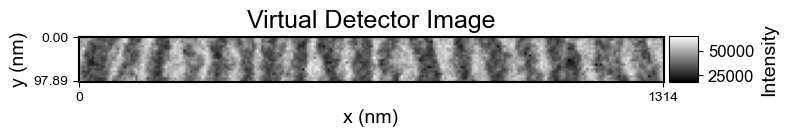

In [41]:
# We visualize a region in which we know the "flat" reference region exists.
y_upper = 95
y_lower = 115

_ = superlattice_data.crop(ylim=(y_upper,y_lower), real_limit_units='pixels').virtual_image(annulus=(35, 50), num_div=(1,1))
del(_)

We automatically identify the most flat regions by finding those diffraction patterns for which the second-order intensities have a low standard deviation. We pick the first 10% of diffraction patterns which exhibit this flat behavior.

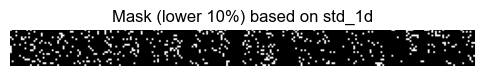

In [45]:
mose2_region_intensities = all_intensities[y_upper:y_lower,:,][:,:,6:12] # Note we pick peaks with indices 6-12 since those are 2nd-order

flat_intensities, flat_mask = mask_and_average(mose2_region_intensities, function='std_1d', percentile=10, threshold='lower', return_mask=True)

We apply the mask to the `all_centers` array to get the **reference** centers-of-mass.

In [46]:
ref_positions = np.mean(all_centers[y_upper:y_lower, :][flat_mask], axis=0)

### 4.2. Strain Mapping Using All 18 Bragg Peaks 

In [47]:
center = superlattice_data.center_beam_metadata['mean_fit_center_px']
center

(62.06338340548037, 62.94193672736449)

In [54]:
ref_positions.shape

(18, 2)

In [49]:
kmin, kmax = 35, 50 # pixels in detector 
centers_mask = ((ref_positions[:,0]-center[0])**2 + (ref_positions[:,1]-center[1])**2)**.5 < kmax
centers_mask = centers_mask & (((ref_positions[:,0]-center[0])**2 + (ref_positions[:,1]-center[1])**2)**.5 > kmin)

In [67]:
all_centers.shape

(199, 256, 18, 2)

In [72]:
intensity_power = 0.5

# Loop over each Bragg peak order 
strain_data = superlattice_data.get_strains(
                                     centers=all_centers[:, :, centers_mask],
                                     ref_centers=ref_positions[centers_mask],
                                     center=center,
                                     intensity_array=all_intensities[:,:,centers_mask]**intensity_power,
                                     intensity_percentile=2.5,
                                     intensity_clip='both',
                                     fit_translation=False,
                                     reject_peak_outliers=False,
                                     outlier_min_peak_pairs=np.round(0.9*len(ref_positions[centers_mask])),
                                     return_transform=True)

Computing strain matrices: 100%|█████████████████████████████████████████████████████| 199/199 [02:05<00:00,  1.58it/s]


In [73]:
meta = strain_data[4]

print("reject_peak_outliers:", meta["reject_peak_outliers"])
print("outlier_min_peak_pairs:", meta["outlier_min_peak_pairs"])
print("initial matched:", np.unique(meta["initial_match_counts"], return_counts=True))
print("kept:", np.unique(meta["match_counts"], return_counts=True))
print("outliers:", np.unique(meta["outlier_counts"], return_counts=True))

reject_peak_outliers: False
outlier_min_peak_pairs: 5
initial matched: (array([4]), array([50944], dtype=int64))
kept: (array([4]), array([50944], dtype=int64))
outliers: (array([0]), array([50944], dtype=int64))


In [ ]:
p = 1

title_fontsize = 16      # adjust panel title size here
cbar_title_fontsize = 10 # adjust colorbar title size here
tick_fontsize = 10       # adjust colorbar tick size here

# Copy so the plotting cell does not permanently modify strain_data
maps = [np.array(strain_data[i], dtype=float, copy=True) for i in range(4)]

# Mean-center each map using all finite pixels
for i in range(4):
    maps[i] -= np.nanmean(maps[i][y_upper:y_lower][flat_mask])

panel_titles = [
    r"$\varepsilon_{xx}$",
    r"$\varepsilon_{yy}$",
    r"$\varepsilon_{xy}$",
    r"$\varepsilon_{rot}$",
]

plot_maps = [
    100 * maps[0],
    100 * maps[1],
    100 * maps[2],
    180 / np.pi * maps[3],
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True, dpi=300)

for idx, (ax, data, title) in enumerate(zip(axes.ravel(), plot_maps, panel_titles)):
    vals = data[np.isfinite(data)]
    lim = np.nanmax(np.abs(np.nanpercentile(vals, [p, 100 - p])))

    im = ax.imshow(data, cmap="RdBu", vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=title_fontsize)
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.08)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    cbar_title = r"Rot. ($^\circ$)" if idx == 3 else "Strain (%)"
    cbar.ax.set_title(cbar_title, fontsize=cbar_title_fontsize, pad=6)

plt.show()

In [124]:
intensity_power = 0.5

# Loop over each Bragg peak order 
strain_data = superlattice_data.get_strains(
                                             centers=all_centers[:, :, :],
                                             ref_centers=ref_positions[:],
                                             center=center,
                                             intensity_array=all_intensities[:,:,:]**intensity_power,
                                             intensity_percentile=2.5,
                                             intensity_clip='both',
                                             fit_translation=False,
                                             reject_peak_outliers=False,
                                             outlier_min_peak_pairs=np.round(0.9*len(ref_positions[:])),
                                             return_transform=True
                                            )

Computing strain matrices: 100%|█████████████████████████████████████████████████████| 199/199 [02:10<00:00,  1.53it/s]


In [125]:
meta = strain_data[4]

print("reject_peak_outliers:", meta["reject_peak_outliers"])
print("outlier_min_peak_pairs:", meta["outlier_min_peak_pairs"])
print("initial matched:", np.unique(meta["initial_match_counts"], return_counts=True))
print("kept:", np.unique(meta["match_counts"], return_counts=True))
print("outliers:", np.unique(meta["outlier_counts"], return_counts=True))

reject_peak_outliers: False
outlier_min_peak_pairs: 16
initial matched: (array([16]), array([50944], dtype=int64))
kept: (array([16]), array([50944], dtype=int64))
outliers: (array([0]), array([50944], dtype=int64))


2.778728319114245e-05
-0.0003591717025082399
-7.76423573412375e-05
-0.00010051399521659755


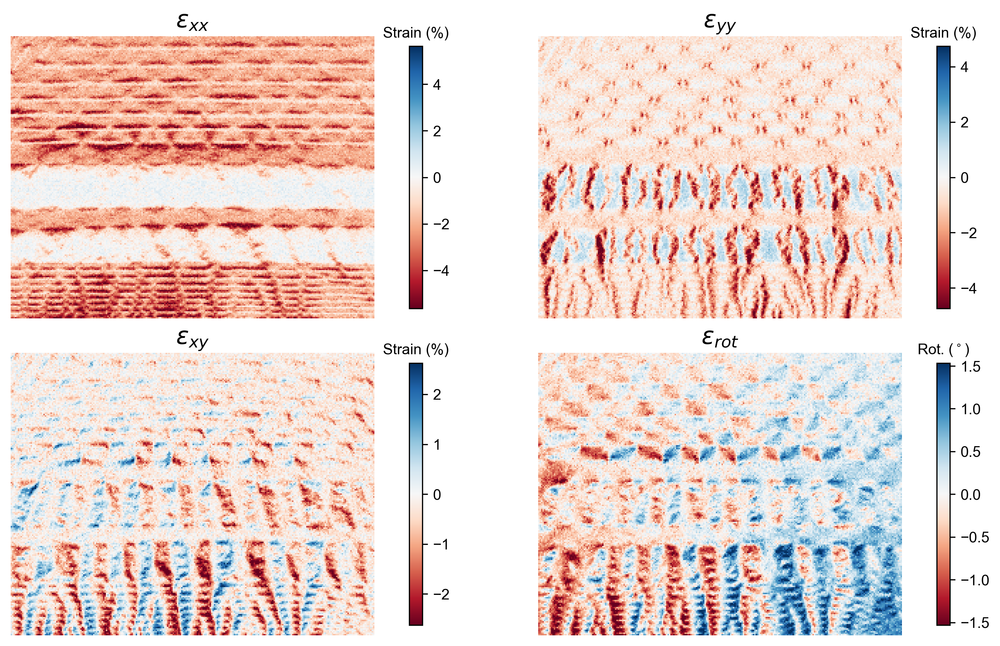

In [109]:
p = 0.5

title_fontsize = 16      # adjust panel title size here
cbar_title_fontsize = 10 # adjust colorbar title size here
tick_fontsize = 10       # adjust colorbar tick size here

# Copy so the plotting cell does not permanently modify strain_data
maps = [np.array(strain_data[i], dtype=float, copy=True) for i in range(4)]

# Mean-center each map using all finite pixels
for i in range(4):
    print(np.nanmean(maps[i][y_upper:y_lower][flat_mask]))
    maps[i] -= np.nanmean(maps[i][y_upper:y_lower][flat_mask])

panel_titles = [
    r"$\varepsilon_{xx}$",
    r"$\varepsilon_{yy}$",
    r"$\varepsilon_{xy}$",
    r"$\varepsilon_{rot}$",
]

plot_maps = [
    100 * maps[0],
    100 * maps[1],
    100 * maps[2],
    180 / np.pi * maps[3],
]

fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True, dpi=300)

for idx, (ax, data, title) in enumerate(zip(axes.ravel(), plot_maps, panel_titles)):
    vals = data[np.isfinite(data)]
    lim = np.nanmax(np.abs(np.nanpercentile(vals, [p, 100 - p])))

    im = ax.imshow(data, cmap="RdBu", vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=title_fontsize)
    ax.axis("off")

    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.08)
    cbar.ax.tick_params(labelsize=tick_fontsize)

    cbar_title = r"Rot. ($^\circ$)" if idx == 3 else "Strain (%)"
    cbar.ax.set_title(cbar_title, fontsize=cbar_title_fontsize, pad=6)

plt.show()

We now find the necessary  rotation of the planar strain components in 2D to properly orient the x and y directions (i.e., we don't want e_xx or e_yy to be inverted or rotated by some random number due to experimental acquisition). To find the x-direction, we use a region with ripples, for the projected compressive strain is maximal when integrated there. Whichever rotation minimizes the pixel-by-pixel sum is considered the rotation we need to find  the necessary rotation.

**Note:** If this angle is known beforehand, it can be introduced directly into `get_strains()` method by using the parameter `ang`.

In [90]:
final_strain_maps = np.zeros((4, all_centers.shape[0], all_centers.shape[1]))

The strain rotation that minimizes the strain sum over the x-direction is 90.1803607214429°


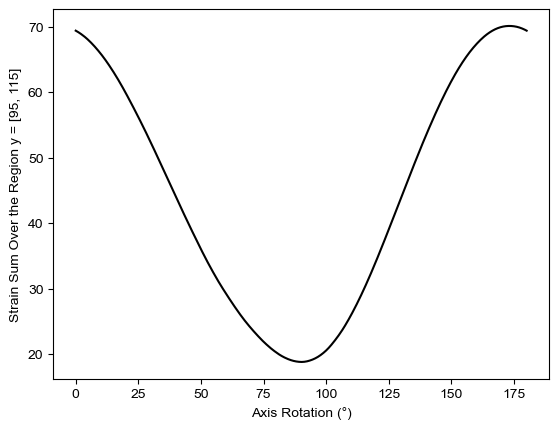

In [118]:
angles = np.linspace(0,180,500)
sums = np.zeros(500)

for i in range(500):

    exx_new, eyy_new, exy_new = rotate_strain(strain_data[0],strain_data[1],strain_data[2], alpha=np.radians(angles[i]))
    sums[i] = np.sum(np.abs(eyy_new[y_upper:y_lower,:]))

rot = angles[np.argmin(sums)]
print(f"The strain rotation that minimizes the strain sum over the x-direction is {rot}°")

plt.plot(angles, sums, c='black')
plt.ylabel(f"Strain Sum Over the Region y = [{y_upper}, {y_lower}]")
plt.xlabel("Axis Rotation (°)")
plt.show()

Rotate the strain components so that x and y are properly oriented.

In [119]:
exx, eyy, exy = rotate_strain(strain_data[0],
                              strain_data[1],
                              strain_data[2], 
                              alpha=np.radians(90))
erot = final_strain_maps[3]

final_strain_maps = np.zeros((4, exx.shape[0], exx.shape[1]))

final_strain_maps[0] = exx
final_strain_maps[1] = eyy
final_strain_maps[2]= exy
final_strain_maps[3] = erot

Visualize the final strain maps (uncorrected)

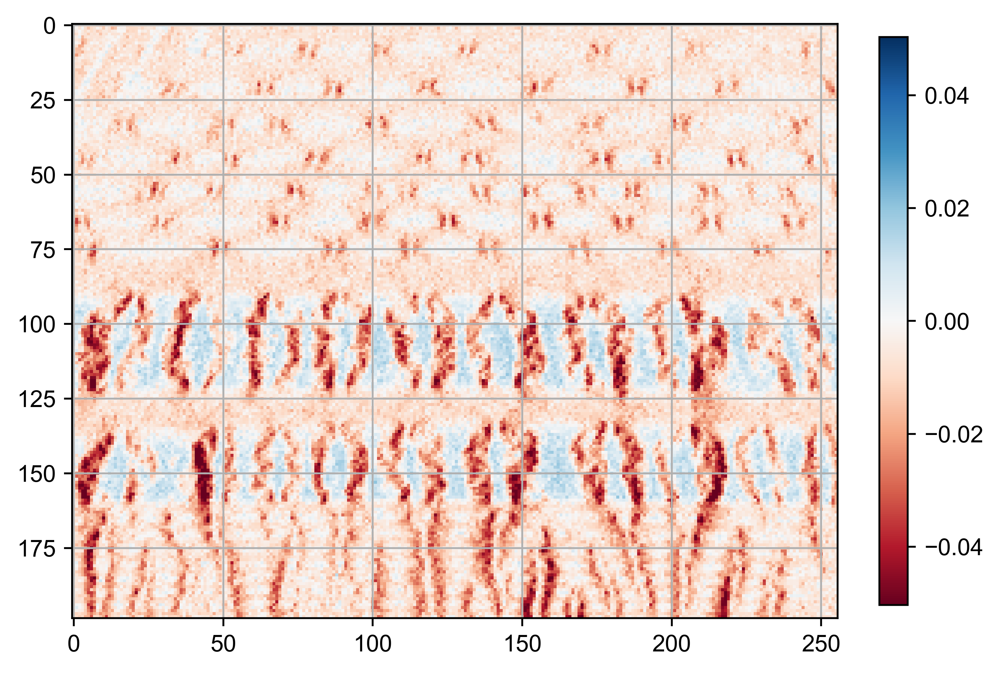

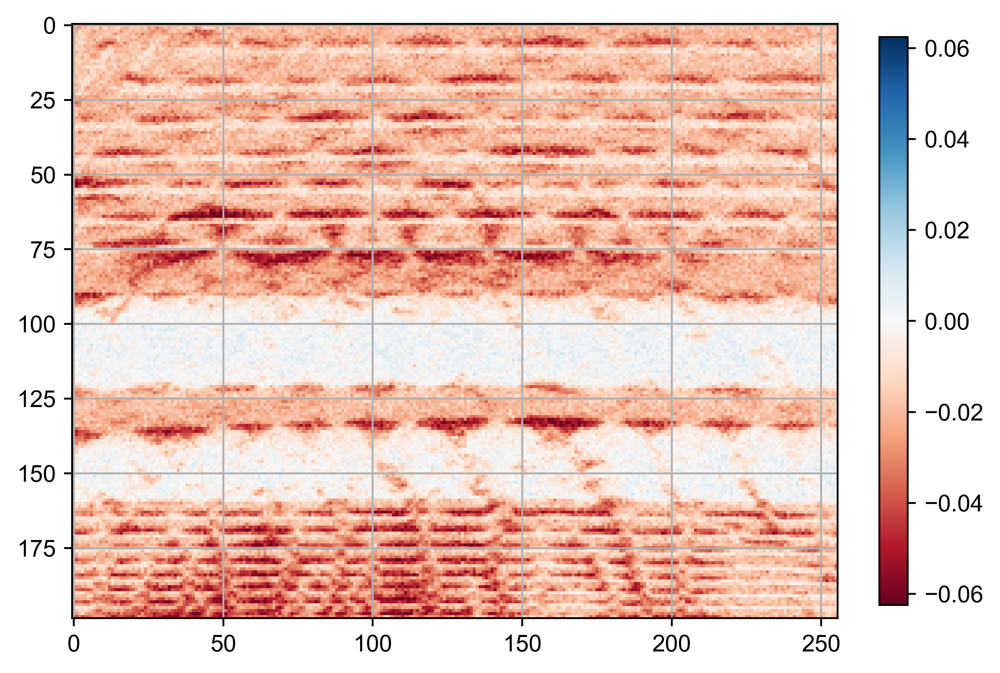

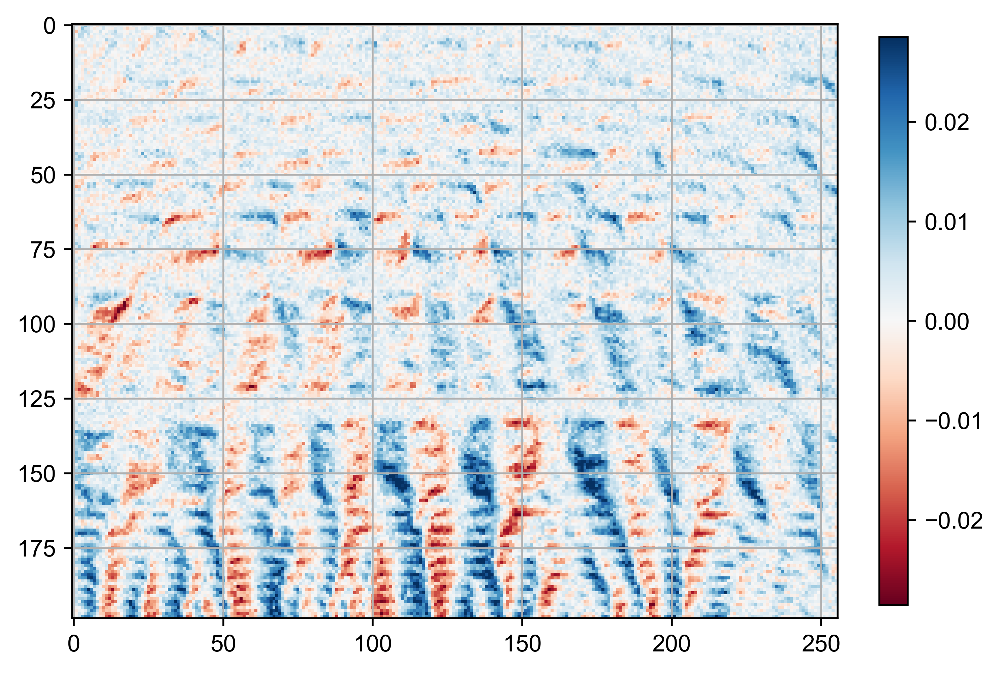

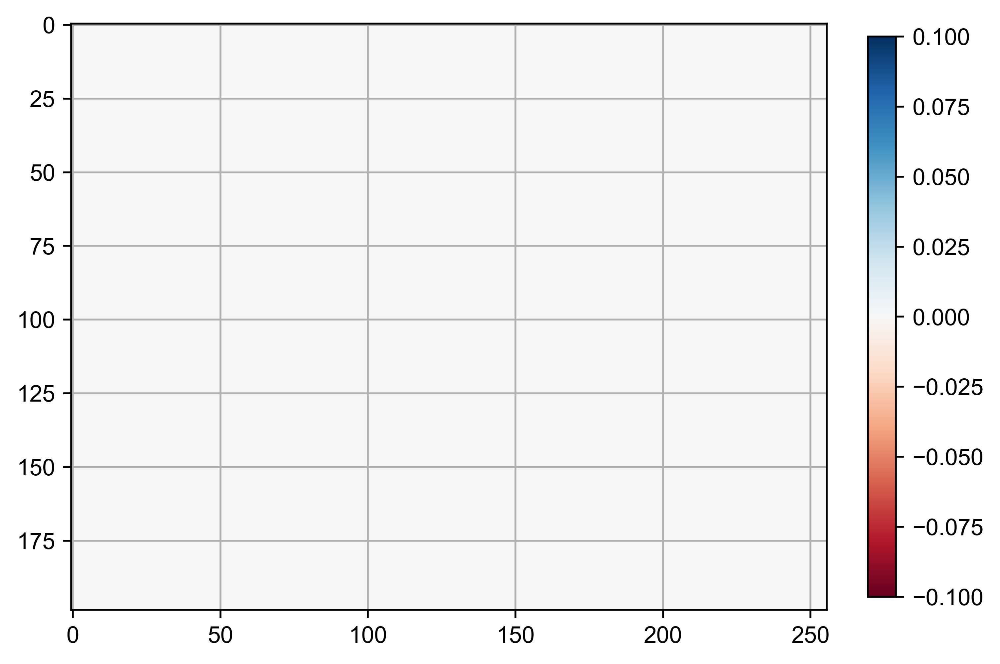

In [120]:
for strain_map in final_strain_maps:
    plt.figure(dpi=500)
    val = np.max(np.abs(strain_map[:150,:]))*0.8
    plt.imshow(strain_map, cmap='RdBu', vmin=-val, vmax=val)
    plt.axis('on')
    plt.grid()
    plt.colorbar(fraction=0.034)
    plt.show()

In [ ]:
# Save the data in .mat format
save_mat_data(exx_data, 
              save_dir + '/exx_rippleData.mat', 
              'exx_rippleData')
save_mat_data(eyy_data, 
              save_dir + '/eyy_rippleData.mat', 
              'eyy_rippleData')
save_mat_data(exy_data, 
              save_dir + '/exy_rippleData.mat', 
              'exy_rippleData')
save_mat_data(erot_data, 
              save_dir + '/erot_rippleData.mat', 
              'erot_rippleData')

### 4.3. Strain Correction

The axis rotation that maximizes strain correction sum over the x-direction is 3.6072144288577155°


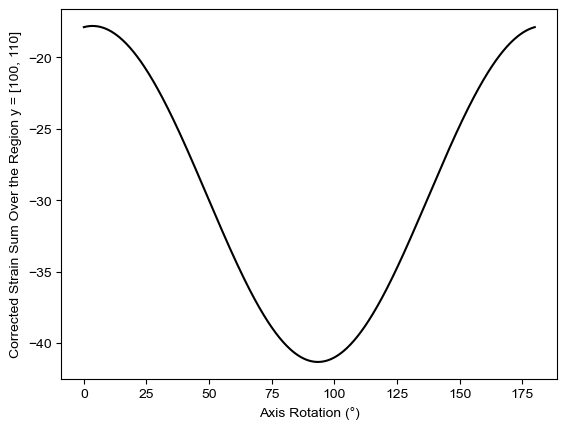

In [355]:
# Find the correction angle
angles = np.linspace(0,180,500)
sums = np.zeros(500)

y_upper, y_lower = 100, 110 

for i in range(500):

    exx_corr, eyy_corr, exy_corr = correct_strain(final_strain_maps[0,], final_strain_maps[1,], final_strain_maps[2,], 
                                              phi= np.radians(angles[i]) + ripple_tilt_axis, 
                                              theta=ripple_tilt)
    sums[i] = np.sum(exx_corr[y_upper:y_lower, :])

rot = angles[np.argmax(sums)]
print(f"The axis rotation that maximizes strain correction sum over the x-direction is {rot}°")

plt.plot(angles, sums, c='black')
plt.ylabel(f"Corrected Strain Sum Over the Region y = [{y_upper}, {y_lower}]")
plt.xlabel("Axis Rotation (°)")
plt.show()

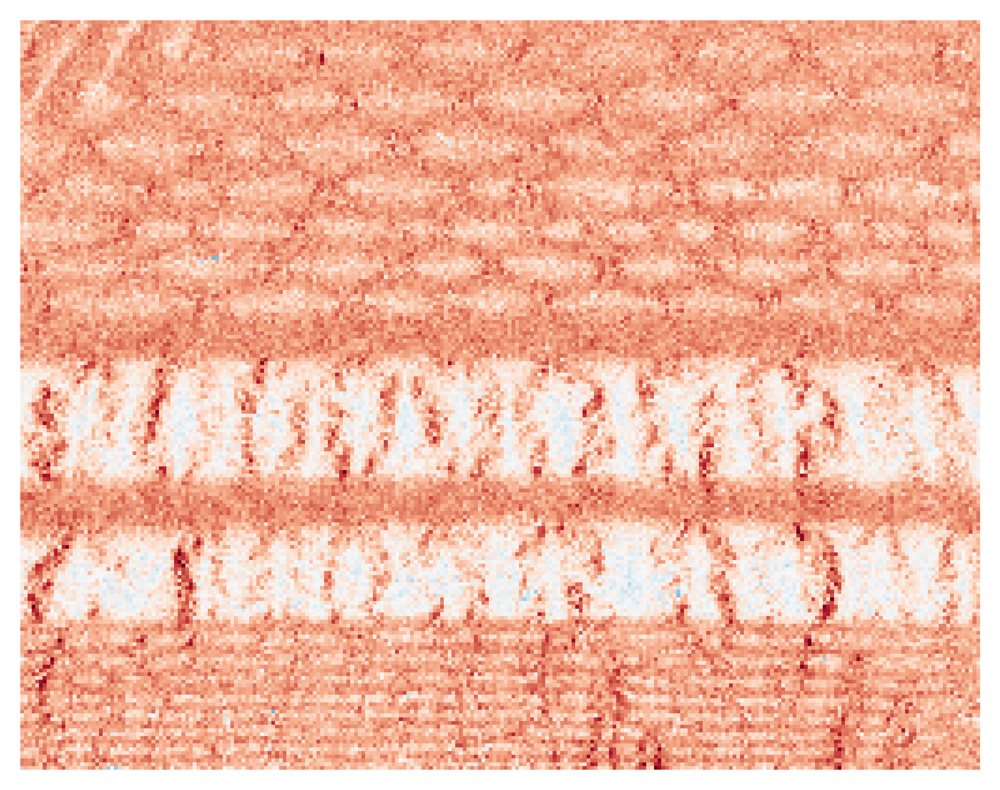

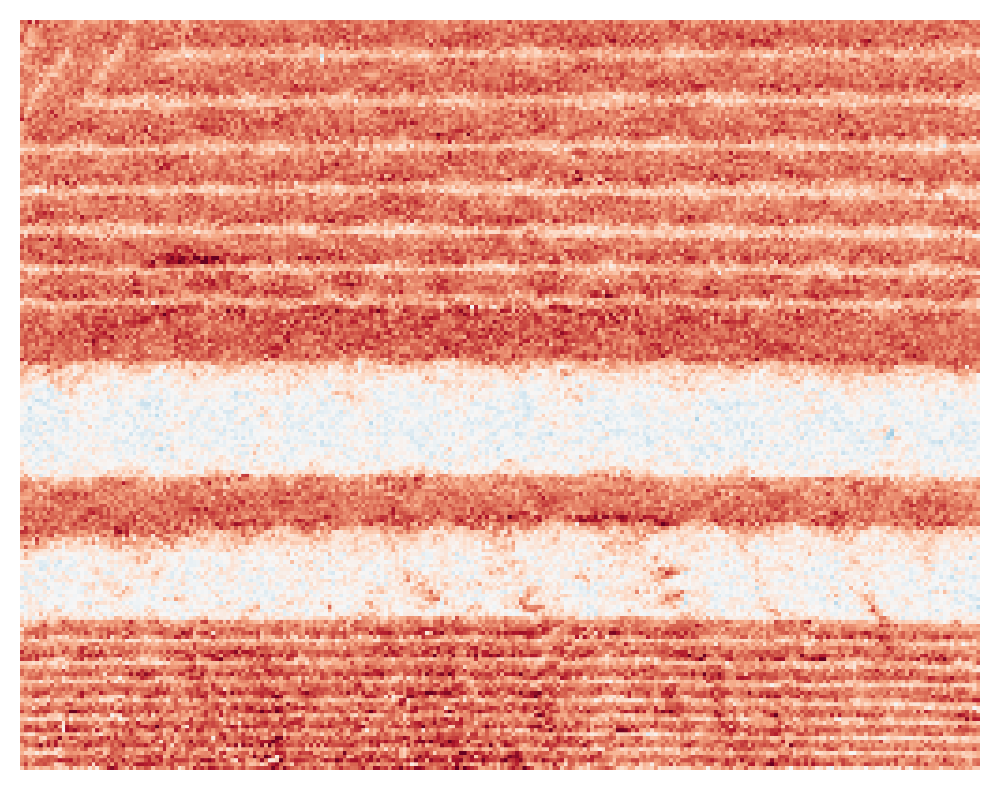

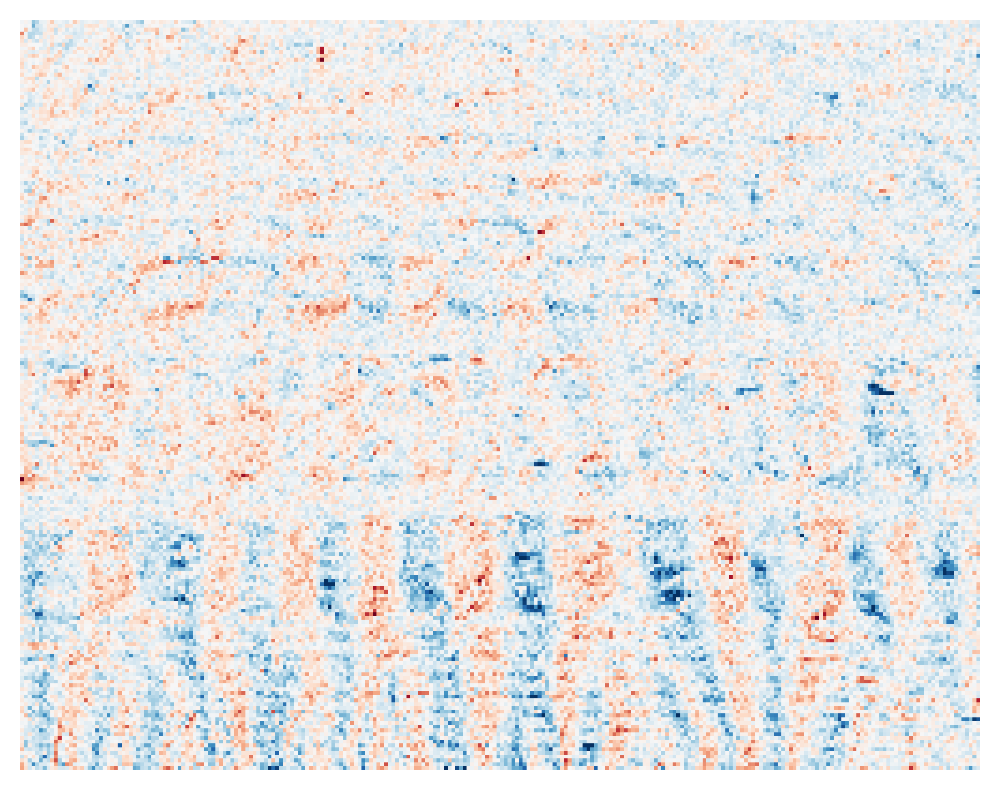

In [479]:
exx_corr, eyy_corr, exy_corr = correct_strain(final_strain_maps[0,], final_strain_maps[1,], final_strain_maps[2,], 
                                              phi=np.radians(rot) + ripple_tilt_axis, 
                                              theta=tilts[:,:,1])

val = 0.04
plt.figure(dpi=500)
plt.imshow(exx_corr, cmap='RdBu', vmin=-val, vmax=val)
plt.axis('off')
# plt.colorbar(fraction=0.034)
plt.show()

val = 0.04
plt.figure(dpi=500)
plt.imshow(eyy_corr, cmap='RdBu', vmin=-val, vmax=val)
plt.axis('off')
# plt.colorbar(fraction=0.034)
plt.show()

val = 0.02
plt.figure(dpi=500)
plt.imshow(exy_corr, cmap='RdBu', vmin=-val, vmax=val)
plt.axis('off')
# plt.colorbar(fraction=0.034)
plt.show()

In [684]:
# Save the correction data in .mat format
save_mat_data(exx_corr, 
              save_dir + '/exx_rippleData_corrected.mat', 
              'exx_rippleData_corrected')
save_mat_data(eyy_corr, 
              save_dir + '/eyy_rippleData_corrected.mat', 
              'eyy_rippleData_corrected')
save_mat_data(exy_corr, 
              save_dir + '/exy_rippleData_corrected.mat', 
              'exy_rippleData_corrected')

The visualize a the mean strain line profile on e_yy. This can be used to estimate widths of the heterojunctions.

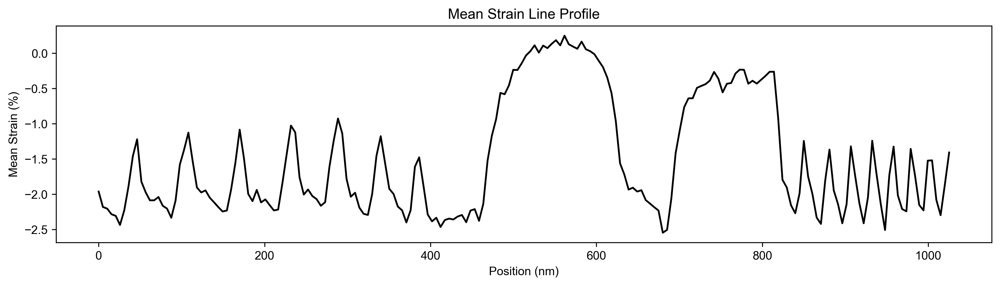

In [413]:
plt.figure(dpi=300, figsize=(21.4*.66, 5*.66))
eyy_corr_flattened = np.mean(eyy_corr[:200, 150:200], axis=1)*100
# plt.scatter(x = np.linspace(1,len(eyy_corr_flattened), len(eyy_corr_flattened)), s=0.5, y = eyy_corr_flattened)
plt.plot(np.arange(len(eyy_corr_flattened))*5.152, eyy_corr_flattened, c='black',) #5.152 nm/px
# plt.axis(False)
# plt.grid()
plt.title("Mean Strain Line Profile")
plt.ylabel("Mean Strain (%)")
plt.xlabel("Position (nm)")
plt.show()